# Gold Price Prediction — Exploratory Data Analysis

Regression on a daily dataset of the Gold ETF (GLD) price along with the S&P 500 index (SPX), oil ETF (USO), silver ETF (SLV), and EUR/USD exchange rate (2008-2018, 2,290 trading days). Target: `GLD` price.

**Target:** `GLD` (continuous)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/gold_price_data.csv')
df['Date'] = pd.to_datetime(df['Date']); df = df.sort_values('Date').reset_index(drop=True)
print('Shape:', df.shape)
df.head()

Shape: (2290, 6)


,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (2290, 6)

Dtypes:
float64           5
datetime64[ns]    1
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,mean,min,25%,50%,75%,max,std
Date,2290,2013-03-17 08:23:41.135371008,2008-01-02 00:00:00,2010-08-20 00:00:00,2013-03-13 12:00:00,2015-10-25 00:00:00,2018-05-16 00:00:00,NaN
SPX,2290.0,1654.315776,676.530029,1239.874969,1551.434998,2073.01007,2872.870117,519.11154
GLD,2290.0,122.732875,70.0,109.725,120.580002,132.840004,184.589996,23.283346
USO,2290.0,31.842221,7.96,14.38,33.869999,37.827501,117.480003,19.523517
SLV,2290.0,20.084997,8.85,15.57,17.2685,22.8825,47.259998,7.092566
EUR/USD,2290.0,1.283653,1.039047,1.171313,1.303297,1.369971,1.598798,0.131547


In [5]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 0
Memory (MB): 0.1


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

No missing values


## 4. Target Variable Distribution

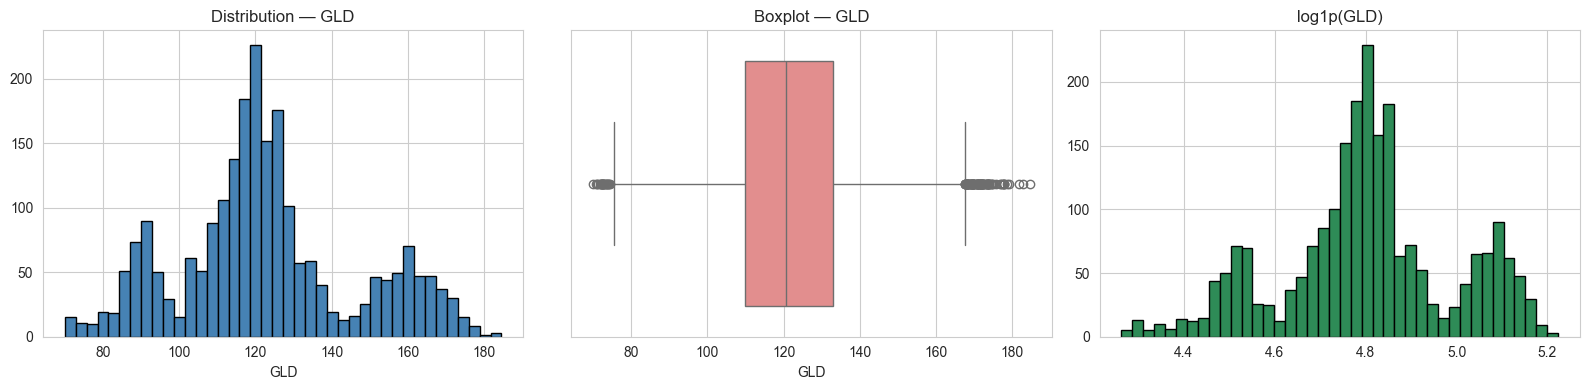

Skewness : 0.334
Kurtosis : -0.275
count    2290.00
mean      122.73
std        23.28
min        70.00
25%       109.73
50%       120.58
75%       132.84
max       184.59
Name: GLD, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['GLD'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — GLD')
axes[0].set_xlabel('GLD')
sns.boxplot(x=df['GLD'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — GLD')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['GLD'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(GLD)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['GLD'].skew(), 3))
print('Kurtosis :', round(df['GLD'].kurtosis(), 3))
print(df['GLD'].describe().round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'GLD' in numeric_cols:
    numeric_cols.remove('GLD')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols[:30])

Numeric features (4):
['SPX', 'USO', 'SLV', 'EUR/USD']


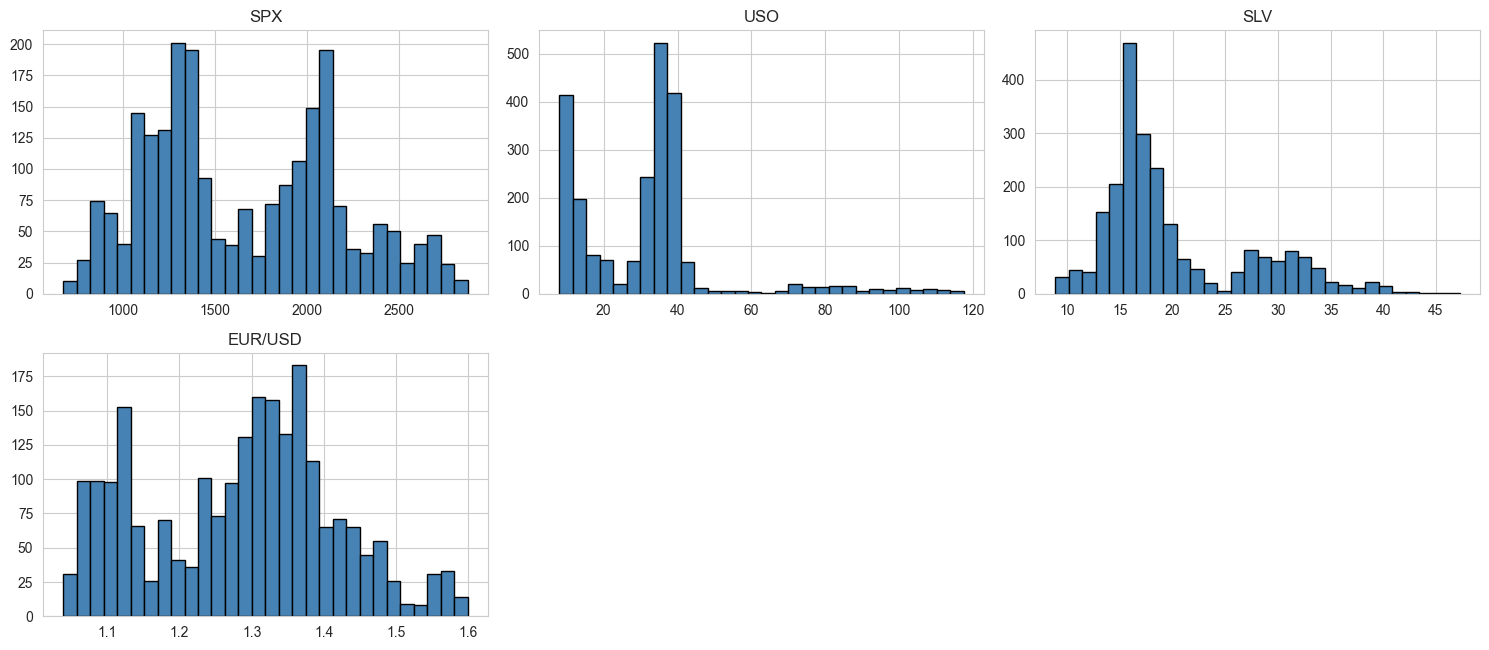

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [10]:
corrs_all = df[numeric_cols + ['GLD']].corr()['GLD'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'GLD'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
SLV        0.867
USO        0.186
SPX        0.049
EUR/USD    0.024
Name: GLD, dtype: float64


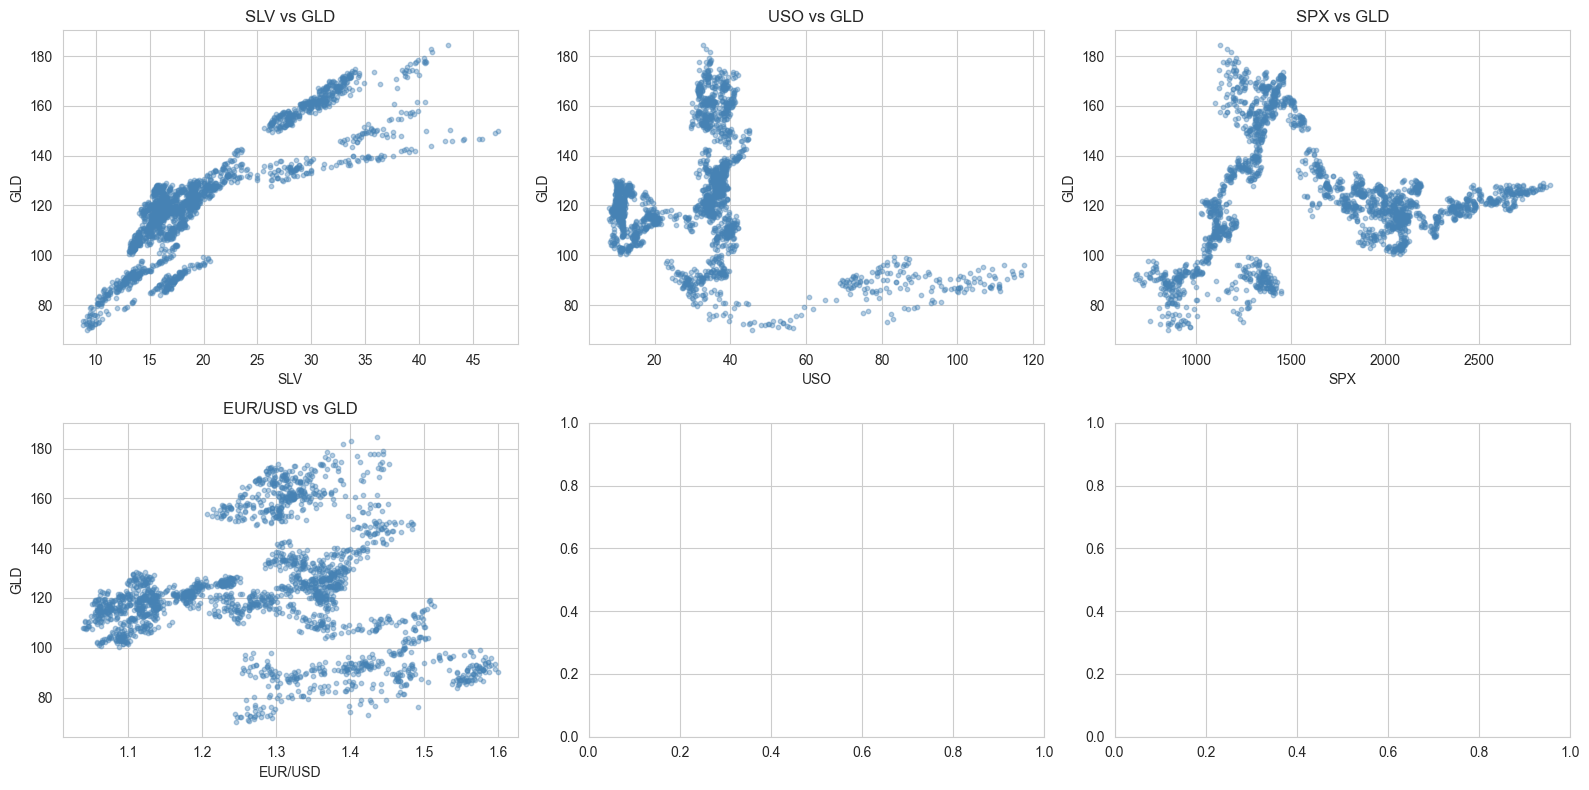

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_features[:6]):
    axes[i].scatter(df[col], df['GLD'], alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(col); axes[i].set_ylabel('GLD')
    axes[i].set_title(f'{col} vs GLD')
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

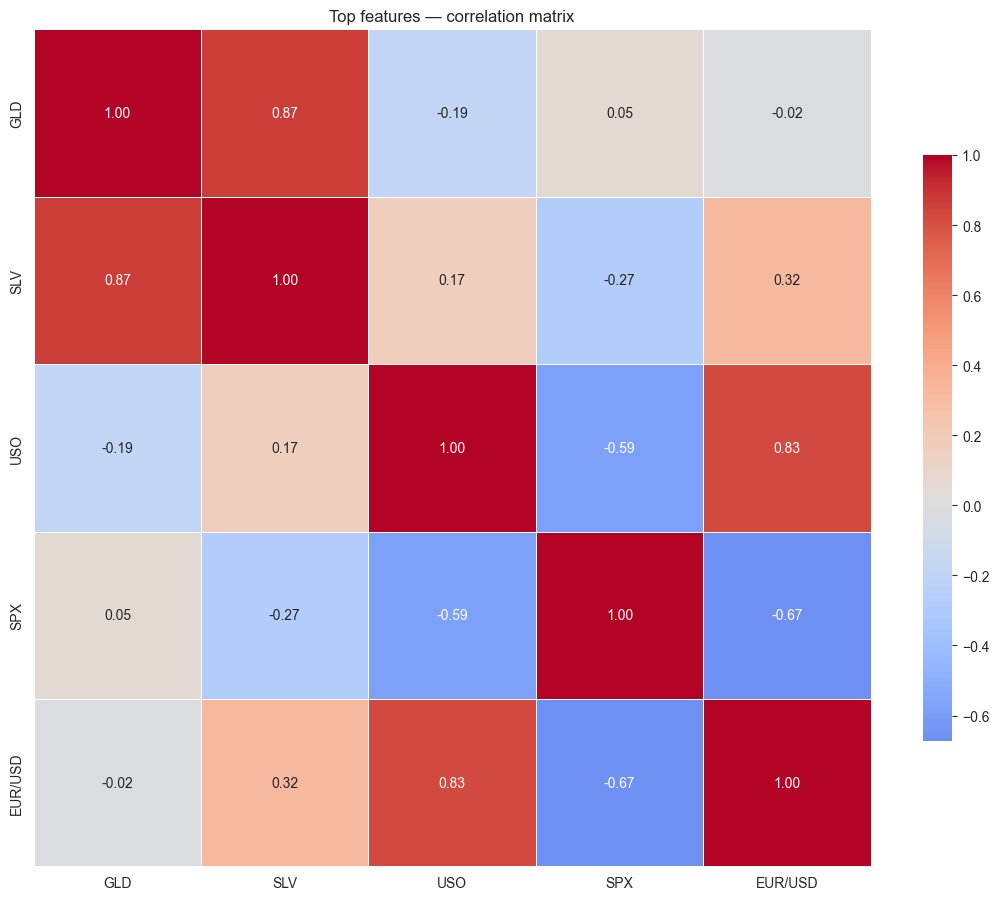

In [12]:
top_numeric = corrs_all.head(15).index.tolist()
if 'GLD' not in top_numeric:
    top_numeric.append('GLD')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

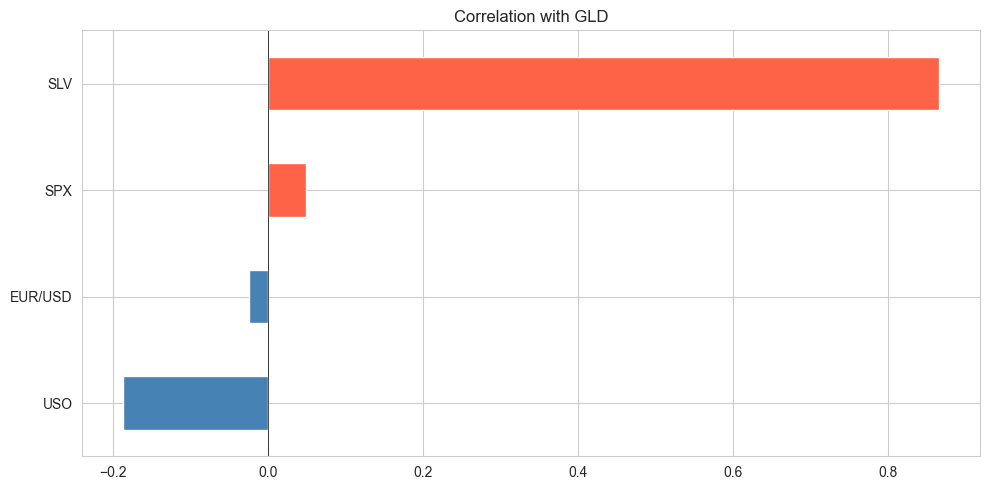

In [13]:
target_corr = df[numeric_cols + ['GLD']].corr()['GLD'].drop('GLD').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with GLD')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Time Series & Cross-Asset Relationships

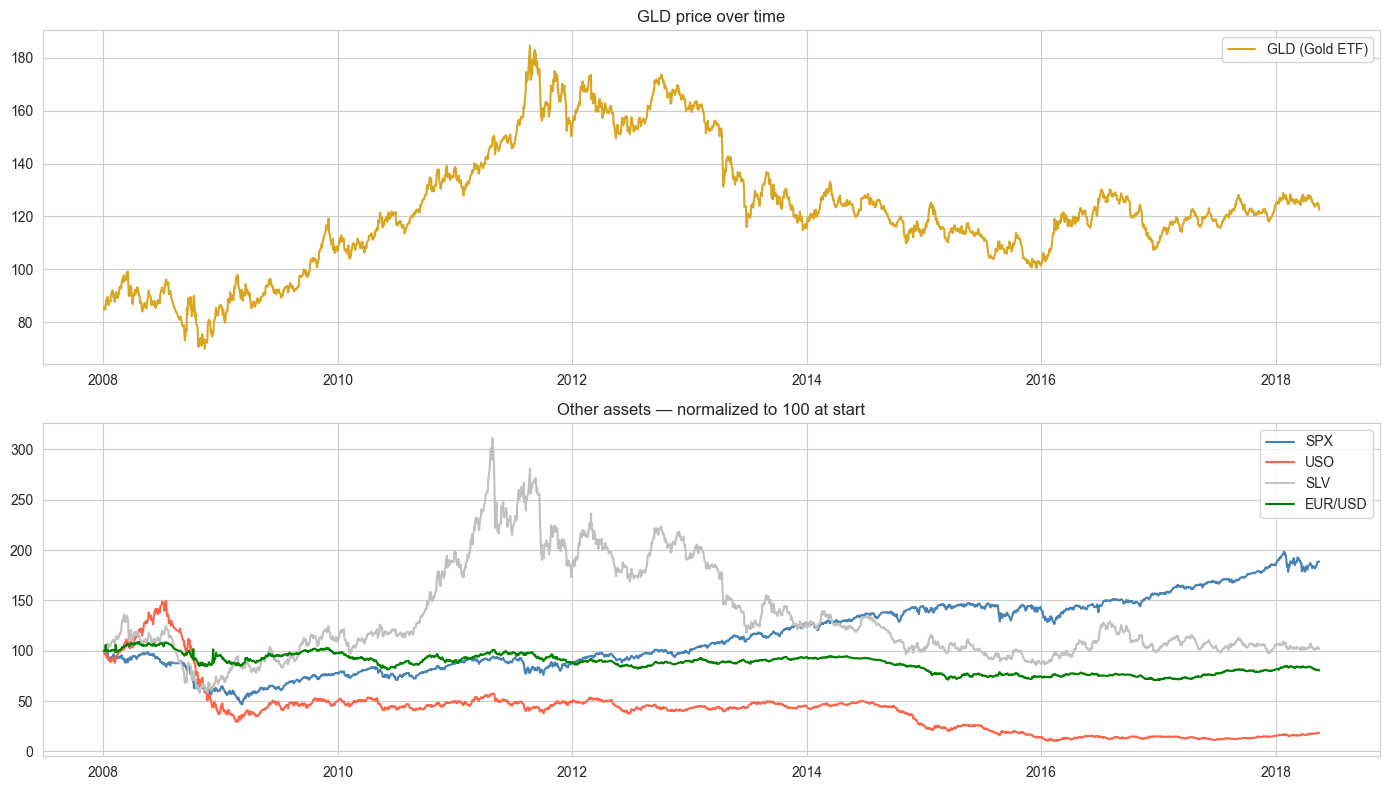

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df['Date'], df['GLD'], color='goldenrod', label='GLD (Gold ETF)')
axes[0].set_title('GLD price over time'); axes[0].legend()
for col, c in [('SPX', 'steelblue'), ('USO', 'tomato'), ('SLV', 'silver'), ('EUR/USD', 'green')]:
    if col in df.columns:
        axes[1].plot(df['Date'], df[col]/df[col].iloc[0]*100, label=col, color=c)
axes[1].set_title('Other assets — normalized to 100 at start')
axes[1].legend(); plt.tight_layout(); plt.show()

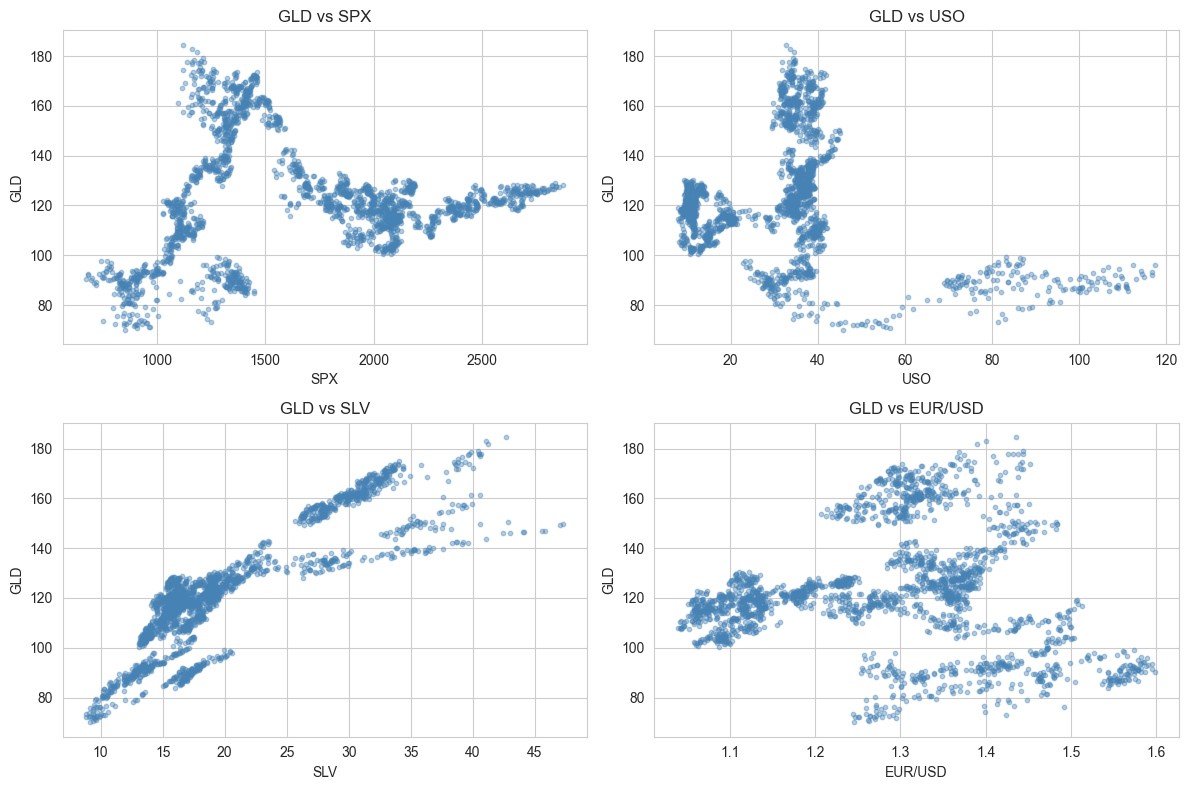

In [15]:
# Scatter: GLD vs each other asset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, ['SPX', 'USO', 'SLV', 'EUR/USD']):
    if col in df.columns:
        ax.scatter(df[col], df['GLD'], alpha=0.4, s=10, color='steelblue')
        ax.set_xlabel(col); ax.set_ylabel('GLD')
        ax.set_title(f'GLD vs {col}')
plt.tight_layout(); plt.show()

## 9. Pair Plot — Top Features

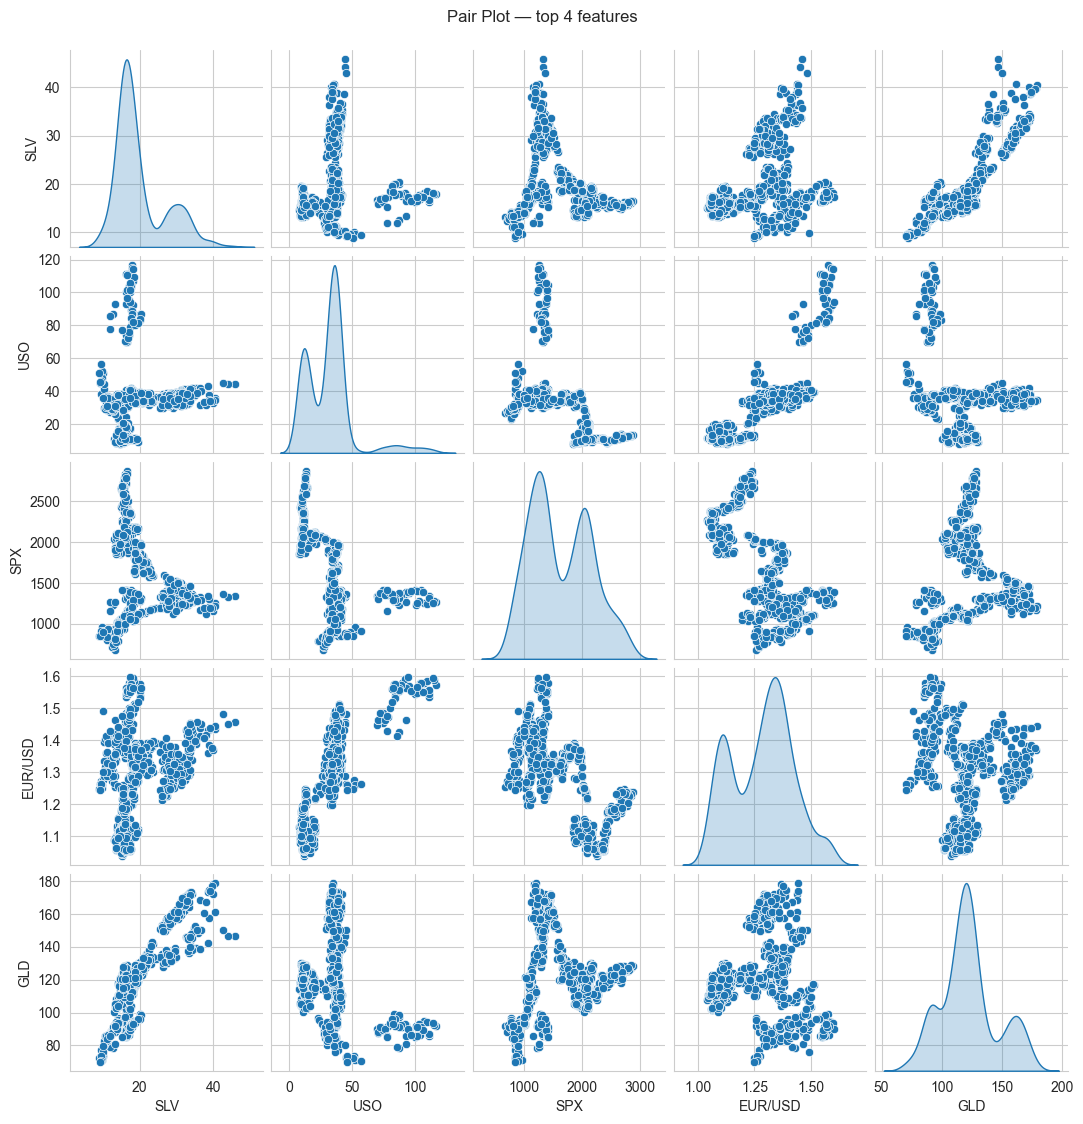

In [16]:
sample = df.sample(min(800, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['GLD']].dropna(), diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [17]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['GLD'].mean(), 2),
        round(df['GLD'].median(), 2),
        round(df['GLD'].std(), 2),
        round(df['GLD'].min(), 2),
        round(df['GLD'].max(), 2),
        round(df['GLD'].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,2290
1,Total features,5
2,Target mean,122.73
3,Target median,120.58
4,Target stddev,23.28
5,Target min,70.0
6,Target max,184.59
7,Target skewness,0.334
8,Top correlated feature,SLV
9,Top correlation value,0.867
